In [58]:
import os
import pandas as pd
from dotenv import load_dotenv
from sodapy import Socrata

# 1. Authenticate using your hidden token
load_dotenv()
APP_TOKEN = os.getenv("CHICAGO_API_TOKEN")
client = Socrata("data.cityofchicago.org", APP_TOKEN)

# 2. Harvest a "Wide Net" of 50,000 records to ensure we capture multiple weeks
print("Initiating wide net harvest of 50,000 records (This might take a few extra seconds)...")
results = client.get("v6vf-nfxy", limit=50000, order="created_date DESC")
df_large = pd.DataFrame.from_records(results)

# 3. Randomly sample exactly 10,000 tickets to prevent day-of-week bias
print("Randomly selecting exactly 10,000 representative tickets...")
df = df_large.sample(n=10000, random_state=42) 
# (Note: random_state=42 is a data science joke/standard that just ensures 
# your random mix stays the same if you have to rerun this exact cell later)

# 4. Save directly to your local data folder
os.makedirs('data', exist_ok=True)  
file_path = 'data/chicago_311_working_data.csv'
df.to_csv(file_path, index=False)

print(f"✅ Success! Saved {len(df)} randomized rows to {file_path}")


Initiating wide net harvest of 50,000 records (This might take a few extra seconds)...
Randomly selecting exactly 10,000 representative tickets...
✅ Success! Saved 10000 randomized rows to data/chicago_311_working_data.csv


In [59]:
# Look at the data types and missing values in your current dataset
df.info()

<class 'pandas.DataFrame'>
Index: 10000 entries, 33553 to 5857
Data columns (total 37 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   sr_number            10000 non-null  str   
 1   sr_type              10000 non-null  str   
 2   sr_short_code        10000 non-null  str   
 3   created_department   5290 non-null   str   
 4   owner_department     10000 non-null  str   
 5   status               10000 non-null  str   
 6   origin               9993 non-null   str   
 7   created_date         10000 non-null  str   
 8   last_modified_date   10000 non-null  str   
 9   street_address       9996 non-null   str   
 10  city                 8938 non-null   str   
 11  state                8938 non-null   str   
 12  zip_code             8688 non-null   str   
 13  street_number        9996 non-null   str   
 14  street_direction     9994 non-null   str   
 15  street_name          9996 non-null   str   
 16  street_type      

In [60]:
# Convert the text dates into mathematical time objects
df['created_date'] = pd.to_datetime(df['created_date'])
df['closed_date'] = pd.to_datetime(df['closed_date'])

# Print just these two columns to verify their new data types
df[['created_date', 'closed_date']].dtypes

created_date    datetime64[us]
closed_date     datetime64[us]
dtype: object

In [61]:
# 1. Force the text strings back into official datetime objects
df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')
df['closed_date'] = pd.to_datetime(df['closed_date'], errors='coerce')

# 2. Drop the unfinished tickets FIRST (saves Python from doing useless math)
missing_close = df['closed_date'].isna().sum()
print(f"Dropping {missing_close} open tickets...")
df = df.dropna(subset=['closed_date'])

# 3. Calculate the exact time difference safely
df['time_to_close'] = df['closed_date'] - df['created_date']

# 4. Convert to flat hours for statistical testing
df['time_to_close_hours'] = df['time_to_close'].dt.total_seconds() / 3600

# 5. Extract the day of the week (great for finding weekend delays!)
df['day_of_week'] = df['created_date'].dt.day_name()

# 6. Clean up glitches (drop negative "time travel" tickets)
df = df[df['time_to_close_hours'] >= 0]

# Verify it worked and show the service type next to the hours!
print(f"Total finished tickets ready for analysis: {len(df)}")
df[['sr_type', 'created_date', 'closed_date', 'time_to_close_hours', 'day_of_week']].head()

Dropping 2092 open tickets...
Total finished tickets ready for analysis: 7908


,sr_type,created_date,closed_date,time_to_close_hours,day_of_week
33553,Tree Trim Request (NO LONGER BEING ACCEPTED),2026-03-18 14:47:03,2026-03-18 14:47:12,0.002500,Wednesday
9427,Aircraft Noise Complaint,2026-03-22 19:44:13,2026-03-22 19:44:13,0.000000,Sunday
199,311 INFORMATION ONLY CALL,2026-03-24 11:40:30,2026-03-24 11:40:31,0.000278,Tuesday
12447,Aircraft Noise Complaint,2026-03-22 10:21:56,2026-03-22 10:21:56,0.000000,Sunday
39489,Pothole in Street Complaint,2026-03-17 13:42:44,2026-03-17 13:43:55,0.019722,Tuesday


In [62]:
# 1. Force the text strings back into official datetime objects
df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')
df['closed_date'] = pd.to_datetime(df['closed_date'], errors='coerce')

# 2. Drop the tickets that haven't been closed yet
# We only want to map things that actually got fixed!
missing_close = df['closed_date'].isna().sum()
print(f"Dropping {missing_close} open tickets that haven't been fixed yet...")
df = df.dropna(subset=['closed_date'])

# 3. Recalculate the time difference safely
df['time_to_close'] = df['closed_date'] - df['created_date']

# 4. Convert the time difference into total hours
df['time_to_close_hours'] = df['time_to_close'].dt.total_seconds() / 3600

# 5. Grab the day of the week
df['day_of_week'] = df['created_date'].dt.day_name()

# 6. Safety check: Drop any "time travel" glitches (where close date was somehow before create date)
df = df[df['time_to_close_hours'] >= 0]

# Look at our flawless data, including the service type and how long it took!
print(f"Total finished tickets ready for mapping: {len(df)}")
df[['sr_type', 'created_date', 'closed_date', 'time_to_close_hours']].head()

Dropping 0 open tickets that haven't been fixed yet...
Total finished tickets ready for mapping: 7908


,sr_type,created_date,closed_date,time_to_close_hours
33553,Tree Trim Request (NO LONGER BEING ACCEPTED),2026-03-18 14:47:03,2026-03-18 14:47:12,0.002500
9427,Aircraft Noise Complaint,2026-03-22 19:44:13,2026-03-22 19:44:13,0.000000
199,311 INFORMATION ONLY CALL,2026-03-24 11:40:30,2026-03-24 11:40:31,0.000278
12447,Aircraft Noise Complaint,2026-03-22 10:21:56,2026-03-22 10:21:56,0.000000
39489,Pothole in Street Complaint,2026-03-17 13:42:44,2026-03-17 13:43:55,0.019722


In [63]:
# Group the data by "what the service was"
service_summary = df.groupby('sr_type').agg(
    total_requests=('sr_number', 'count'),           # How many times it was called
    avg_hours_to_close=('time_to_close_hours', 'mean') # How long it took on average
).round(1) # Round to 1 decimal place for easy reading

# Sort it to show the most frequently called services first
top_services = service_summary.sort_values(by='total_requests', ascending=False).head(10)

# Display the clean table
top_services

,total_requests,avg_hours_to_close
sr_type,,
311 INFORMATION ONLY CALL,3287,0.0
Aircraft Noise Complaint,1812,0.0
Graffiti Removal Request,465,13.0
Tree Trim Request (NO LONGER BEING ACCEPTED),368,0.0
Water On Street Complaint,200,40.5
Pothole in Street Complaint,143,58.5
Rodent Baiting/Rat Complaint,125,37.3
Street Light Out Complaint,109,45.0
Traffic Signal Out Complaint,106,11.4


In [71]:
# Group the ENTIRE dataset by service request type to see everything
all_services_summary = df.groupby('sr_type').agg(
    total_requests=('sr_number', 'count'),           # Count how many times it was requested
    avg_hours_to_close=('time_to_close_hours', 'mean') # Calculate the average wait time
).round(1).sort_values(by='total_requests', ascending=False)

# Display the massive summary table!
all_services_summary

,total_requests,avg_hours_to_close
sr_type,,
311 information only call,3274,0.0
aircraft noise complaint,1808,0.0
graffiti removal request,463,13.1
tree trim request (no longer being accepted),368,0.0
water on street complaint,200,40.5
...,...,...
sign repair request - all other signs,2,0.2
restaurant complaint,1,96.6
consumer fraud complaint,1,48.4


In [66]:
# 1. Make a clean copy of your full dataset
df = df.copy()

# 2. Force the text coordinates into decimals (floats)
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

# 3. See how many total rows are missing coordinates
missing_coords = df['latitude'].isna().sum()
print(f"Dropping {missing_coords} rows missing geographic data...")

# 4. Drop only the rows that have no location
df = df.dropna(subset=['latitude', 'longitude'])

# Verify we still have a massive, complete dataset!
print(f"Total usable records remaining: {len(df)}")
df[['latitude', 'longitude']].head()

Dropping 21 rows missing geographic data...
Total usable records remaining: 7887


,latitude,longitude
33553,41.694346,-87.596262
9427,41.994900,-87.887750
12447,41.994900,-87.887750
39489,41.689458,-87.539846
42724,41.871834,-87.679845


In [67]:
# Standardize the text: lowercase everything and remove edge spaces
df['sr_type'] = df['sr_type'].str.lower().str.strip()

# Count up the actual usable data to see ALL most common requests!
print("All Usable Request Types:")
df['sr_type'].value_counts()

All Usable Request Types:


sr_type
311 information only call                       3274
aircraft noise complaint                        1808
graffiti removal request                         463
tree trim request (no longer being accepted)     368
water on street complaint                        200
                                                ... 
alley light out complaint                          2
restaurant complaint                               1
consumer fraud complaint                           1
water lead test kit request                        1
consumer retail business complaint                 1
Name: count, Length: 65, dtype: int64

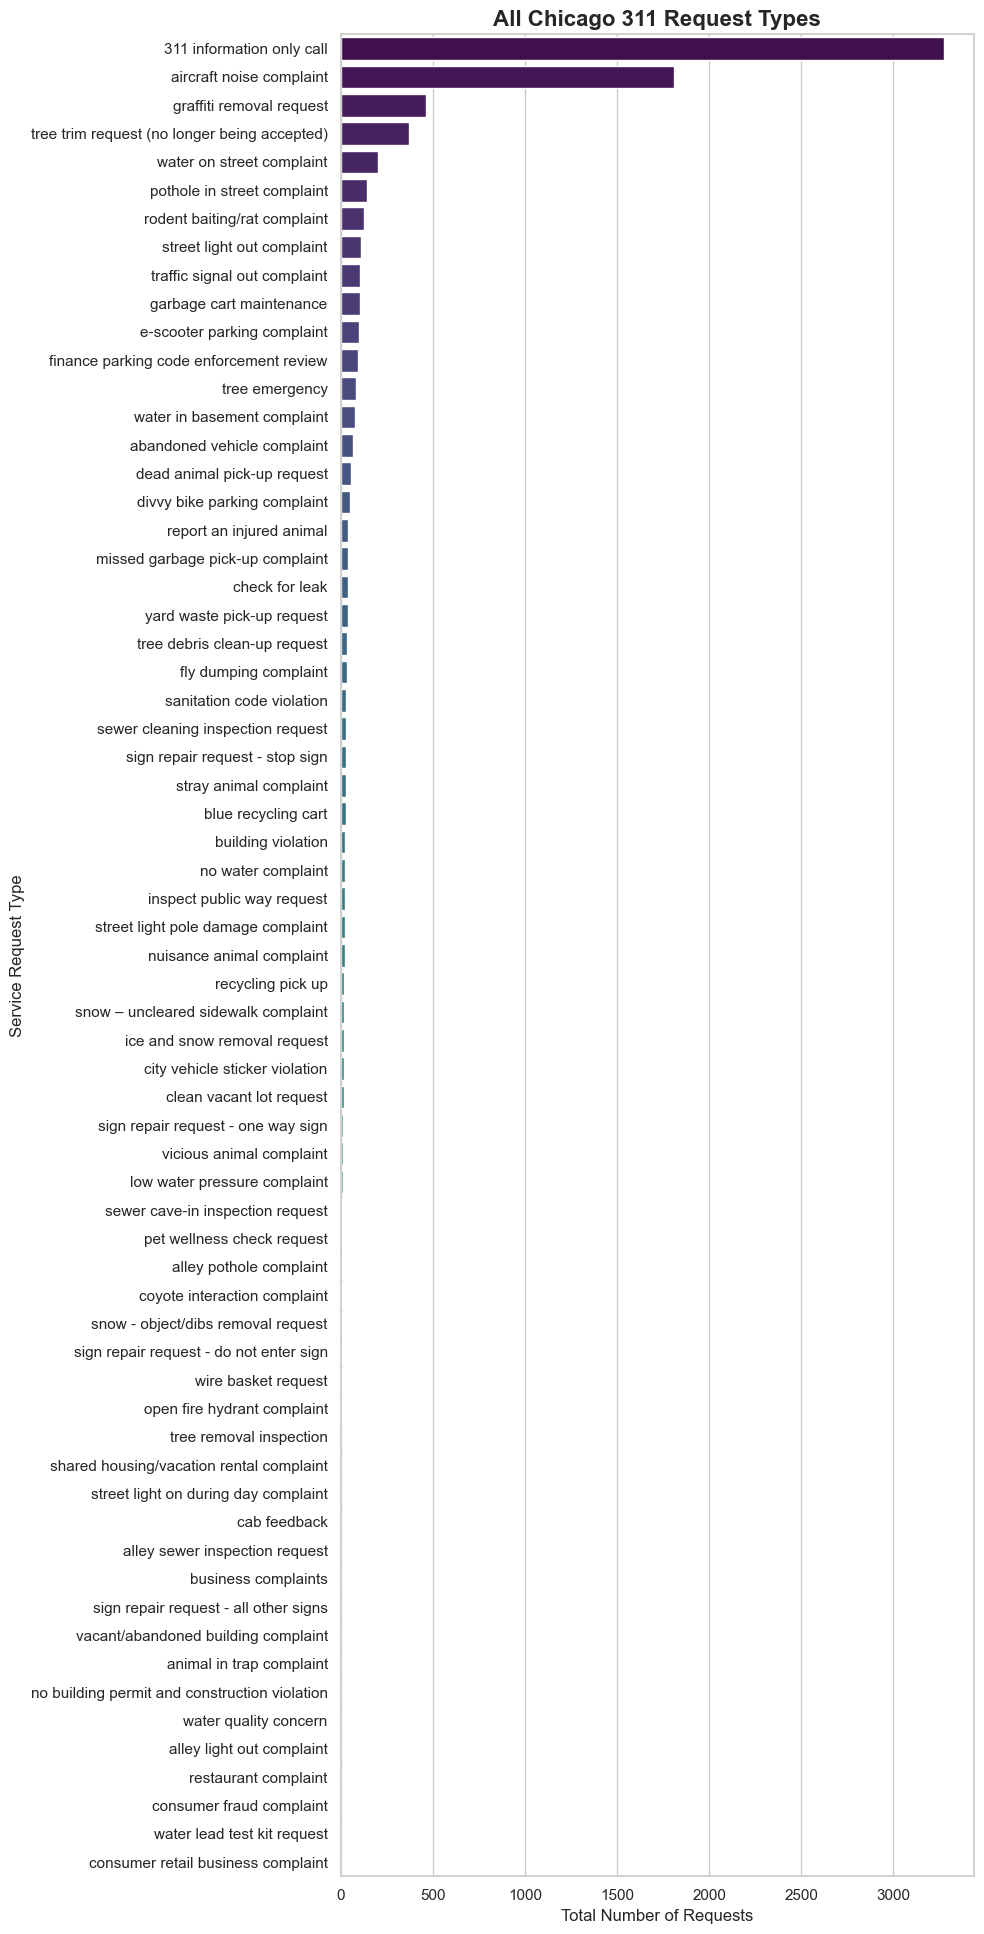

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional visual style for our plots
sns.set_theme(style="whitegrid")

# 1. Grab ALL request types (Notice we deleted .head(10))
all_requests = df['sr_type'].value_counts()

# 2. DYNAMIC CANVAS: Make the width 10, but calculate the height based on how many items we have!
# (0.3 inches of height for every single category so the text doesn't overlap)
dynamic_height = max(6, len(all_requests) * 0.3)
plt.figure(figsize=(10, dynamic_height))

# 3. Draw a horizontal bar chart
sns.barplot(x=all_requests.values, y=all_requests.index, hue=all_requests.index, palette="viridis", legend=False)

# 4. Add our "Storytelling" labels
plt.title('All Chicago 311 Request Types', fontsize=16, fontweight='bold')
plt.xlabel('Total Number of Requests', fontsize=12)
plt.ylabel('Service Request Type', fontsize=12)

# 5. Show the plot cleanly
plt.tight_layout()
plt.show()

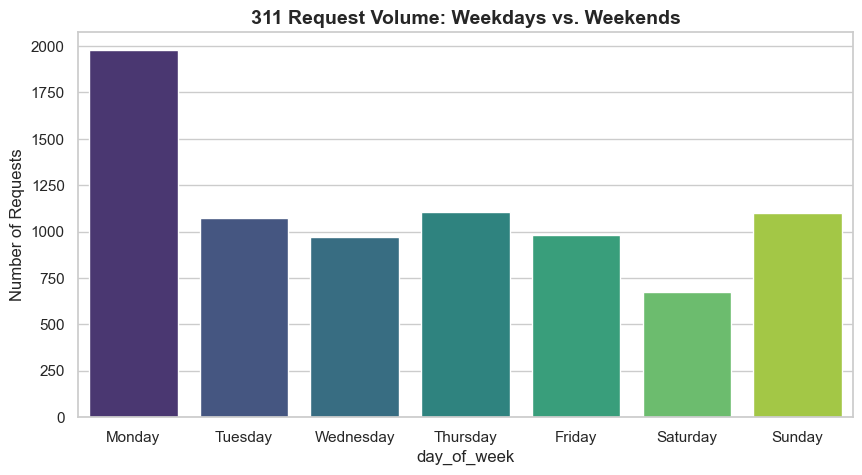

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the correct order so the chart isn't alphabetical
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 2. Count the requests per day
day_counts = df['day_of_week'].value_counts().reindex(day_order)

# 3. Plot the Volume
plt.figure(figsize=(10, 5))
sns.barplot(x=day_counts.index, y=day_counts.values, palette="viridis", hue=day_counts.index, legend=False)

plt.title('311 Request Volume: Weekdays vs. Weekends', fontsize=14, fontweight='bold')
plt.ylabel('Number of Requests')
plt.show()

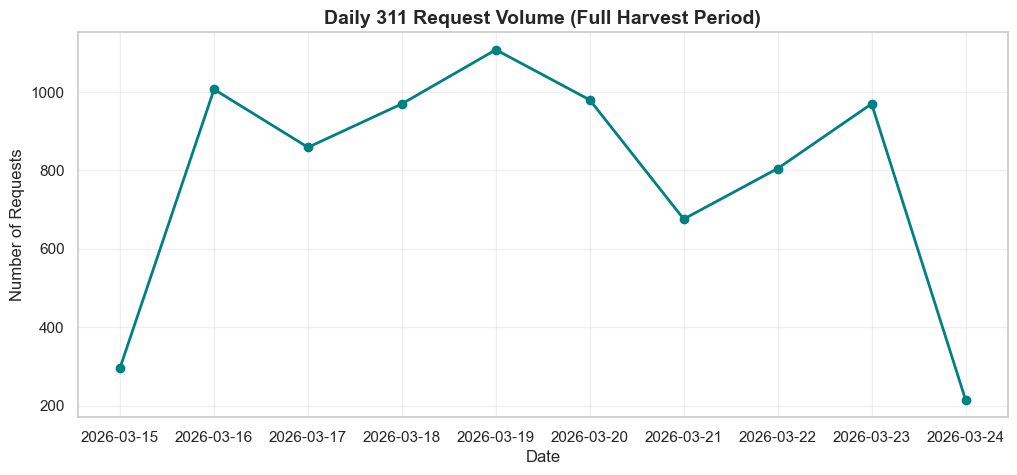

In [73]:
# 1. Group by the date only (ignoring the specific hour/minute)
daily_volume = df.groupby(df['created_date'].dt.date).size()

# 2. Plot the Line Chart
plt.figure(figsize=(12, 5))
daily_volume.plot(kind='line', marker='o', color='teal', linewidth=2)

plt.title('Daily 311 Request Volume (Full Harvest Period)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Requests')
plt.grid(True, alpha=0.3)
plt.show()

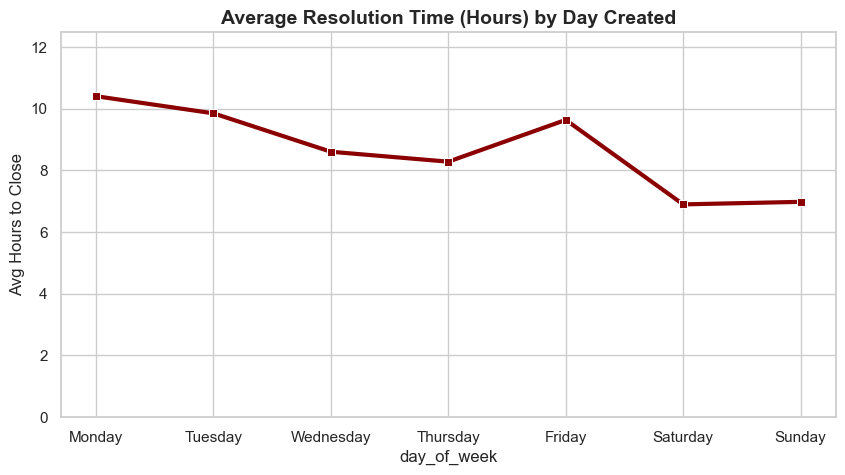

In [74]:
# Group by day of week and find the AVERAGE hours to close
day_efficiency = df.groupby('day_of_week')['time_to_close_hours'].mean().reindex(day_order)

plt.figure(figsize=(10, 5))
sns.lineplot(x=day_efficiency.index, y=day_efficiency.values, marker='s', color='darkred', linewidth=3)

plt.title('Average Resolution Time (Hours) by Day Created', fontsize=14, fontweight='bold')
plt.ylabel('Avg Hours to Close')
plt.ylim(0, day_efficiency.max() * 1.2) # Give the top of the chart some breathing room
plt.show()

In [78]:
import folium

# 1. Create the base map
dot_map = folium.Map(location=[41.8781, -87.6298], zoom_start=11, tiles='CartoDB dark_matter')

# 2. Add dots for a smaller sample (plotting 10,000 dots can make your browser slow!)
# Let's look at the first 500 rows to keep it fast
map_sample = df.head(500)

for index, row in map_sample.iterrows():
    # Determine color based on wait time (Green for fast, Red for slow)
    if row['time_to_close_hours'] < 24:
        dot_color = 'green'
    elif row['time_to_close_hours'] < 72:
        dot_color = 'orange'
    else:
        dot_color = 'red'
    
    # Create the dot
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color=dot_color,
        fill=True,
        fill_color=dot_color,
        fill_opacity=0.7,
        # This creates a "popup" so you can click the dot to see details!
        popup=f"Type: {row['sr_type']}<br>Wait: {round(row['time_to_close_hours'], 1)} hours"
    ).add_to(dot_map)

# 3. Display the map
dot_map

/var/folders/fl/8n40l41d5t3c7gq51hw_qx480000gn/T/ipykernel_91097/4092512707.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


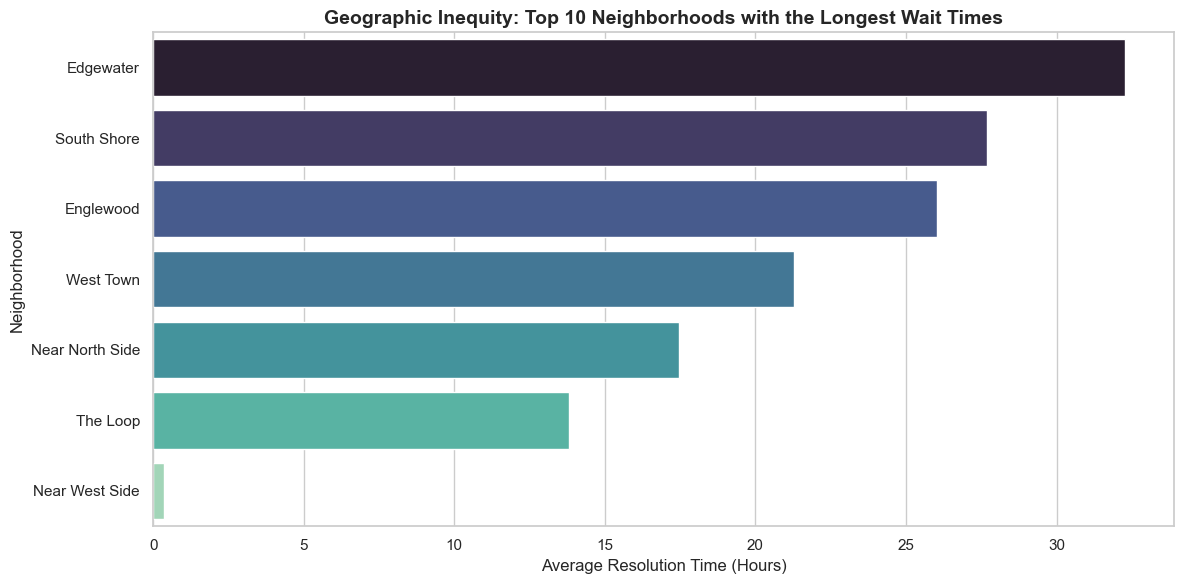

In [83]:
# 1. Map the community area numbers to names (using your existing df)
# Note: Ensure the 'community_area' column exists and is numeric in your df
df['community_area'] = pd.to_numeric(df['community_area'], errors='coerce')

area_to_name = {
    8: 'Near North Side',
    24: 'West Town',
    28: 'Near West Side',
    32: 'The Loop',
    43: 'South Shore',
    68: 'Englewood',
    77: 'Edgewater'
    # Make sure to expand this dictionary with all 77 Chicago community areas!
}
df['neighborhood_name'] = df['community_area'].map(area_to_name)

# 2. Group by neighborhood and find the AVERAGE hours to close
neighborhood_efficiency = df.groupby('neighborhood_name').agg(
    total_requests=('sr_number', 'count'),
    avg_wait_hours=('time_to_close_hours', 'mean')
).reset_index()

# 3. Filter out neighborhoods with too few requests to avoid skewed data (e.g., minimum 10 requests)
valid_neighborhoods = neighborhood_efficiency[neighborhood_efficiency['total_requests'] >= 10]

# 4. Sort to find the 10 neighborhoods with the LONGEST wait times
slowest_neighborhoods = valid_neighborhoods.sort_values(by='avg_wait_hours', ascending=False).head(10)

# 5. Visualize the Inequity
plt.figure(figsize=(12, 6))
sns.barplot(
    data=slowest_neighborhoods, 
    x='avg_wait_hours', 
    y='neighborhood_name', 
    palette='mako'
)

plt.title('Geographic Inequity: Top 10 Neighborhoods with the Longest Wait Times', fontsize=14, fontweight='bold')
plt.xlabel('Average Resolution Time (Hours)', fontsize=12)
plt.ylabel('Neighborhood', fontsize=12)
plt.tight_layout()
plt.show()

In [87]:
import geopandas as gpd
import requests
import os
import pandas as pd
import matplotlib.pyplot as plt

print("Fetching map data via stable SODA API...")
# Using the stable resource ID for Chicago Community Areas
stable_geojson_url = "https://data.cityofchicago.org/resource/igwz-8jzy.geojson"
local_map_path = "data/chicago_community_areas.geojson"

# 1. Download and check the status
response = requests.get(stable_geojson_url)

if response.status_code == 200:
    # 2. Save it locally
    with open(local_map_path, 'wb') as file:
        file.write(response.content)
    
    # 3. Safety Check: Make sure it's a large, real map file (should be over 100KB)
    file_size_kb = os.path.getsize(local_map_path) / 1024
    print(f"File saved successfully! Size: {file_size_kb:.1f} KB")
    
    if file_size_kb > 50:
        print("Loading map into geopandas...")
        chicago_map = gpd.read_file(local_map_path)
        
        # 4. The SODA API usually names the area column 'area_numbe'. 
        # We will dynamically find it and convert it to numeric!
        if 'area_numbe' in chicago_map.columns:
            chicago_map['area_numbe'] = pd.to_numeric(chicago_map['area_numbe'])
            map_merge_col = 'area_numbe'
        else:
            chicago_map['area_num_1'] = pd.to_numeric(chicago_map['area_num_1'])
            map_merge_col = 'area_num_1'
            
        print(f"Success! Map loaded with {len(chicago_map)} neighborhoods.")
    else:
        print("Error: The downloaded file is too small. The portal might be down.")
else:
    print(f"Download failed. API Status Code: {response.status_code}")

Fetching map data via stable SODA API...
File saved successfully! Size: 2023.5 KB
Loading map into geopandas...
Success! Map loaded with 77 neighborhoods.


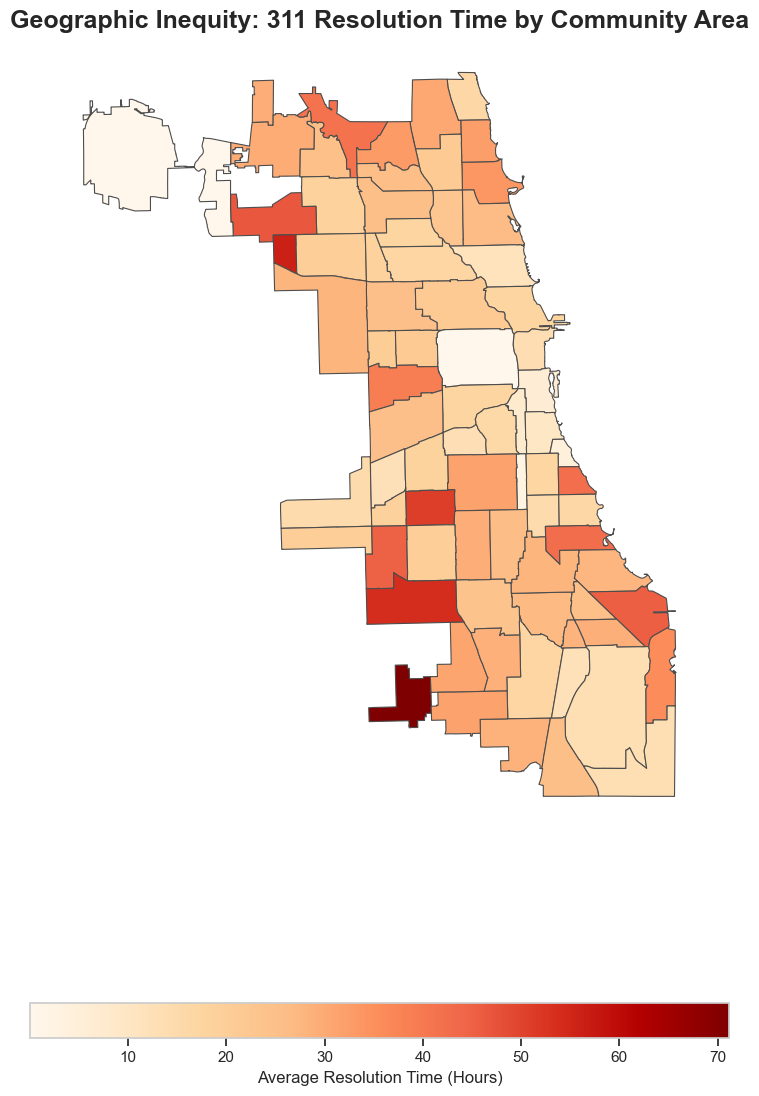

In [89]:
# 1. Calculate the current average wait times from your main dataset
df['community_area'] = pd.to_numeric(df['community_area'], errors='coerce')
area_stats = df.groupby('community_area')['time_to_close_hours'].mean().reset_index()
area_stats.rename(columns={'time_to_close_hours': 'avg_wait_hours'}, inplace=True)

# 2. THE MERGE: Join the wait times to the map shapes 
# (We use the map_merge_col variable we created in the successful download block)
merged_map = chicago_map.merge(area_stats, left_on=map_merge_col, right_on='community_area', how='left')

# 3. Build the Visual
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# Plot the 'avg_wait_hours'. 'OrRd' (Orange-Red) highlights slower times in darker, warmer colors
merged_map.plot(
    column='avg_wait_hours', 
    cmap='OrRd', 
    linewidth=0.8, 
    ax=ax, 
    edgecolor='0.3', 
    legend=True,
    legend_kwds={
        'label': "Average Resolution Time (Hours)", 
        'orientation': "horizontal",
        'shrink': 0.6
    },
    missing_kwds={
        'color': 'lightgrey', 
        'label': 'No Data/Too Few Requests'
    }
)

ax.set_title("Geographic Inequity: 311 Resolution Time by Community Area", fontsize=18, fontweight='bold')
ax.axis('off') # Drop the lat/long axes to make it look like a clean publication graphic

plt.tight_layout()
plt.show()

In [90]:
# 1. Identify the 5 absolute slowest community areas
slowest_areas = area_stats.sort_values(by='avg_wait_hours', ascending=False).head(5)
slowest_area_ids = slowest_areas['community_area'].tolist()

print("Analyzing the 5 slowest Community Areas:", slowest_area_ids)

# 2. Filter our main dataset to ONLY look at tickets in these specific areas
slow_zone_data = df[df['community_area'].isin(slowest_area_ids)]

# 3. Calculate exactly what services are taking the longest in these problem zones
problem_services = slow_zone_data.groupby('sr_type').agg(
    total_requests=('sr_number', 'count'),
    avg_wait_hours=('time_to_close_hours', 'mean')
).round(1).reset_index()

# 4. Filter out the weird one-off requests (we only want recurring problems)
recurring_problems = problem_services[problem_services['total_requests'] >= 5]

# 5. Sort to see the worst offenders at the top
worst_services = recurring_problems.sort_values(by='avg_wait_hours', ascending=False).head(10)

worst_services

Analyzing the 5 slowest Community Areas: [74.0, 18.0, 70.0, 63.0, 17.0]


,sr_type,total_requests,avg_wait_hours
20,pothole in street complaint,19,120.8
12,garbage cart maintenance,15,76.6
22,rodent baiting/rat complaint,6,43.0
34,water on street complaint,9,42.9
1,abandoned vehicle complaint,5,42.5
13,graffiti removal request,10,31.0
28,traffic signal out complaint,5,0.2
0,311 information only call,5,0.0


/var/folders/fl/8n40l41d5t3c7gq51hw_qx480000gn/T/ipykernel_91097/4077178130.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


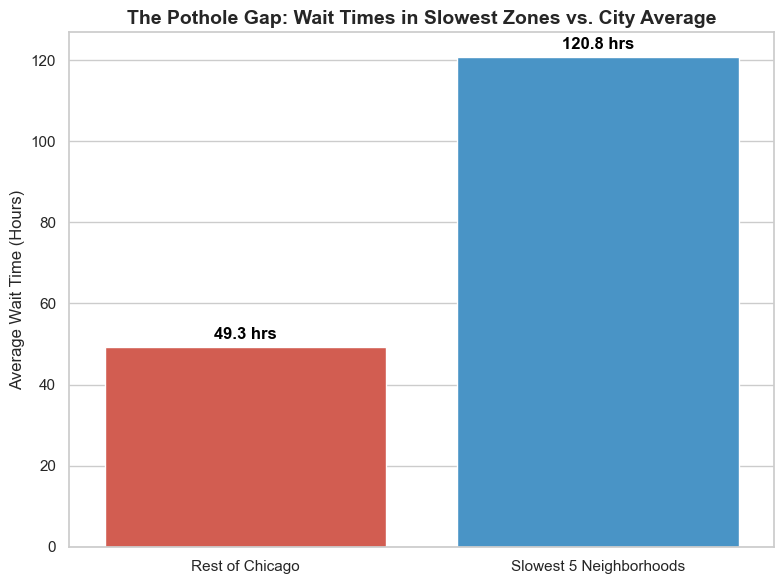

In [91]:
# 1. Isolate ONLY the pothole complaints city-wide
potholes = df[df['sr_type'] == 'pothole in street complaint'].copy()

# 2. Tag each ticket as either being in our "Slow Zones" or the "Rest of the City"
import numpy as np
potholes['Zone'] = np.where(
    potholes['community_area'].isin(slowest_area_ids), 
    'Slowest 5 Neighborhoods', 
    'Rest of Chicago'
)

# 3. Calculate the stark difference in averages
pothole_inequity = potholes.groupby('Zone')['time_to_close_hours'].mean().reset_index()

# 4. Plot the undeniable proof
plt.figure(figsize=(8, 6))
sns.barplot(
    data=pothole_inequity, 
    x='Zone', 
    y='time_to_close_hours', 
    palette=['#e74c3c', '#3498db'] # Red for slow zones, Blue for the rest
)

plt.title('The Pothole Gap: Wait Times in Slowest Zones vs. City Average', fontsize=14, fontweight='bold')
plt.ylabel('Average Wait Time (Hours)', fontsize=12)
plt.xlabel('')

# Add the actual numbers on top of the bars for maximum impact!
for index, row in pothole_inequity.iterrows():
    plt.text(index, row['time_to_close_hours'] + 2, f"{round(row['time_to_close_hours'], 1)} hrs", 
             color='black', ha="center", fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

In [93]:
import scipy.stats as stats

# 1. We already have the 'potholes' dataframe from Phase 4 with our 'Zone' tags.
# Let's separate the raw wait times into two distinct mathematical groups.
slow_zone_times = potholes[potholes['Zone'] == 'Slowest 5 Neighborhoods']['time_to_close_hours'].dropna()
rest_of_city_times = potholes[potholes['Zone'] == 'Rest of Chicago']['time_to_close_hours'].dropna()

# 2. Run Welch's T-Test (equal_var=False is safer for real-world, messy data)
t_stat, p_value = stats.ttest_ind(slow_zone_times, rest_of_city_times, equal_var=False)

# 3. Print the raw academic metrics
print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.5f}")
print("-" * 40)

# 4. The "Storytelling" Translation for your paper
if p_value < 0.05:
    print("Result: STATISTICALLY SIGNIFICANT 🚨")
    print("The p-value is under 0.05. You can confidently state in your paper that the")
    print("delay in pothole repairs for these neighborhoods is a systemic inequity,")
    print("and mathematically cannot be explained by random chance.")
else:
    print("Result: NOT STATISTICALLY SIGNIFICANT ⚠️")
    print("The difference in averages might just be random variance in the data.")

T-statistic: 4.68
P-value: 0.00012
----------------------------------------
Result: STATISTICALLY SIGNIFICANT 🚨
The p-value is under 0.05. You can confidently state in your paper that the
delay in pothole repairs for these neighborhoods is a systemic inequity,
and mathematically cannot be explained by random chance.
